In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("IPL DATA ANALYSIS").getOrCreate()

In [ ]:
if 'spark' in locals() and isinstance(spark, SparkSession):
    print("SparkSession is active and ready to use.")
else:
    print("SparkSession is not active. Please create a SparkSession.")

SparkSession is active and ready to use.


In [ ]:
from pyspark.sql.types import StructField, StructType, DateType, IntegerType, LongType, StringType, BooleanType, DataType, DecimalType
from pyspark.sql.functions import col, when, sum, avg, row_number
from pyspark.sql.window import Window

In [ ]:
from pyspark.sql.types import *

ball_by_ball_schema = StructType([
    StructField("match_id", IntegerType(), True),
    StructField("over_id", IntegerType(), True),
    StructField("ball_id", IntegerType(), True),
    StructField("innings_no", IntegerType(), True),
    StructField("team_batting", StringType(), True),
    StructField("team_bowling", StringType(), True),
    StructField("striker_batting_position", IntegerType(), True),
    StructField("extra_type", StringType(), True),
    StructField("runs_scored", IntegerType(), True),
    StructField("extra_runs", IntegerType(), True),
    StructField("wides", IntegerType(), True),
    StructField("legbyes", IntegerType(), True),
    StructField("byes", IntegerType(), True),
    StructField("noballs", IntegerType(), True),
    StructField("penalty", IntegerType(), True),
    StructField("bowler_extras", IntegerType(), True),
    StructField("out_type", StringType(), True),
    StructField("caught", BooleanType(), True),
    StructField("bowled", BooleanType(), True),
    StructField("run_out", BooleanType(), True),
    StructField("lbw", BooleanType(), True),
    StructField("retired_hurt", BooleanType(), True),
    StructField("stumped", BooleanType(), True),
    StructField("caught_and_bowled", BooleanType(), True),
    StructField("hit_wicket", BooleanType(), True),
    StructField("obstructingfeild", BooleanType(), True),
    StructField("bowler_wicket", BooleanType(), True),
    StructField("match_date", DateType(), True),
    StructField("season", IntegerType(), True),
    StructField("striker", IntegerType(), True),
    StructField("non_striker", IntegerType(), True),
    StructField("bowler", IntegerType(), True),
    StructField("player_out", IntegerType(), True),
    StructField("fielders", IntegerType(), True),
    StructField("striker_match_sk", IntegerType(), True),
    StructField("strikersk", IntegerType(), True),
    StructField("nonstriker_match_sk", IntegerType(), True),
    StructField("nonstriker_sk", IntegerType(), True),
    StructField("fielder_match_sk", IntegerType(), True),
    StructField("fielder_sk", IntegerType(), True),
    StructField("bowler_match_sk", IntegerType(), True),
    StructField("bowler_sk", IntegerType(), True),
    StructField("playerout_match_sk", IntegerType(), True),
    StructField("battingteam_sk", IntegerType(), True),
    StructField("bowlingteam_sk", IntegerType(), True),
    StructField("keeper_catch", BooleanType(), True),
    StructField("player_out_sk", IntegerType(), True),
    StructField("matchdatesk", DateType(), True),
])

In [ ]:
ball_df=spark.read.schema(ball_by_ball_schema).format("csv").option("header","true").load("/content/drive/MyDrive/Ipl-data-till-2017/Ball_By_Ball.csv")
ball_df.printSchema()
ball_df.show(5)

root
 |-- match_id: integer (nullable = true)
 |-- over_id: integer (nullable = true)
 |-- ball_id: integer (nullable = true)
 |-- innings_no: integer (nullable = true)
 |-- team_batting: string (nullable = true)
 |-- team_bowling: string (nullable = true)
 |-- striker_batting_position: integer (nullable = true)
 |-- extra_type: string (nullable = true)
 |-- runs_scored: integer (nullable = true)
 |-- extra_runs: integer (nullable = true)
 |-- wides: integer (nullable = true)
 |-- legbyes: integer (nullable = true)
 |-- byes: integer (nullable = true)
 |-- noballs: integer (nullable = true)
 |-- penalty: integer (nullable = true)
 |-- bowler_extras: integer (nullable = true)
 |-- out_type: string (nullable = true)
 |-- caught: boolean (nullable = true)
 |-- bowled: boolean (nullable = true)
 |-- run_out: boolean (nullable = true)
 |-- lbw: boolean (nullable = true)
 |-- retired_hurt: boolean (nullable = true)
 |-- stumped: boolean (nullable = true)
 |-- caught_and_bowled: boolean (null

In [ ]:
match_schema = StructType([
    StructField("match_sk", IntegerType(), True),
    StructField("match_id", IntegerType(), True),
    StructField("team1", StringType(), True),
    StructField("team2", StringType(), True),
    StructField("match_date", DateType(), True),
    StructField("season_year", IntegerType(), True),
    StructField("venue_name", StringType(), True),
    StructField("city_name", StringType(), True),
    StructField("country_name", StringType(), True),
    StructField("toss_winner", StringType(), True),
    StructField("match_winner", StringType(), True),
    StructField("toss_name", StringType(), True),
    StructField("win_type", StringType(), True),
    StructField("outcome_type", StringType(), True),
    StructField("manofmach", StringType(), True),
    StructField("win_margin", IntegerType(), True),
    StructField("country_id", IntegerType(), True)
])

match_df=spark.read.schema(match_schema).format("csv").option("header","true").load("/content/drive/MyDrive/Ipl-data-till-2017/Match.csv")
match_df.show(5)

+--------+--------+--------------------+--------------------+----------+-----------+--------------------+----------+------------+--------------------+--------------------+---------+--------+------------+-----------+----------+----------+
|match_sk|match_id|               team1|               team2|match_date|season_year|          venue_name| city_name|country_name|         toss_winner|        match_winner|toss_name|win_type|outcome_type|  manofmach|win_margin|country_id|
+--------+--------+--------------------+--------------------+----------+-----------+--------------------+----------+------------+--------------------+--------------------+---------+--------+------------+-----------+----------+----------+
|       0|  335987|Royal Challengers...|Kolkata Knight Ri...|      NULL|       2008|M Chinnaswamy Sta...| Bangalore|       India|Royal Challengers...|Kolkata Knight Ri...|    field|    runs|      Result|BB McCullum|       140|         1|
|       1|  335988|     Kings XI Punjab| Chennai

In [ ]:
player_schema = StructType([
    StructField("player_sk", IntegerType(), True),
    StructField("player_id", IntegerType(), True),
    StructField("player_name", StringType(), True),
    StructField("dob", DateType(), True),
    StructField("batting_hand", StringType(), True),
    StructField("bowling_skill", StringType(), True),
    StructField("country_name", StringType(), True)
])
player_df=spark.read.schema(player_schema).format("csv").option("header","true").load("/content/drive/MyDrive/Ipl-data-till-2017/Player.csv")
player_df.show(5)

+---------+---------+---------------+----+--------------+------------------+------------+
|player_sk|player_id|    player_name| dob|  batting_hand|     bowling_skill|country_name|
+---------+---------+---------------+----+--------------+------------------+------------+
|        0|        1|     SC Ganguly|NULL| Left-hand bat|  Right-arm medium|       India|
|        1|        2|    BB McCullum|NULL|Right-hand bat|  Right-arm medium| New Zealand|
|        2|        3|     RT Ponting|NULL|Right-hand bat|  Right-arm medium|   Australia|
|        3|        4|      DJ Hussey|NULL|Right-hand bat|Right-arm offbreak|   Australia|
|        4|        5|Mohammad Hafeez|NULL|Right-hand bat|Right-arm offbreak|    Pakistan|
+---------+---------+---------------+----+--------------+------------------+------------+
only showing top 5 rows


In [ ]:
player_match_schema = StructType([
    StructField("player_match_sk", IntegerType(), True),
    StructField("playermatch_key", DecimalType(18, 2), True),
    StructField("match_id", IntegerType(), True),
    StructField("player_id", IntegerType(), True),
    StructField("player_name", StringType(), True),
    StructField("dob", DateType(), True),
    StructField("batting_hand", StringType(), True),
    StructField("bowling_skill", StringType(), True),
    StructField("country_name", StringType(), True),
    StructField("role_desc", StringType(), True),
    StructField("player_team", StringType(), True),
    StructField("opposit_team", StringType(), True),
    StructField("season_year", IntegerType(), True),
    StructField("is_manofthematch", BooleanType(), True),
    StructField("age_as_on_match", IntegerType(), True),
    StructField("isplayers_team_won", BooleanType(), True),
    StructField("batting_status", StringType(), True),
    StructField("bowling_status", StringType(), True),
    StructField("player_captain", StringType(), True),
    StructField("opposit_captain", StringType(), True),
    StructField("player_keeper", StringType(), True),
    StructField("opposit_keeper", StringType(), True)
])
player_match_df=spark.read.schema(player_match_schema).format("csv").option("header","true").load("/content/drive/MyDrive/Ipl-data-till-2017/Player_match.csv")
player_match_df.show(5)

+---------------+---------------+--------+---------+-----------+----+--------------+--------------------+------------+---------+--------------------+--------------------+-----------+----------------+---------------+------------------+--------------+--------------+--------------+---------------+-------------+--------------+
|player_match_sk|playermatch_key|match_id|player_id|player_name| dob|  batting_hand|       bowling_skill|country_name|role_desc|         player_team|        opposit_team|season_year|is_manofthematch|age_as_on_match|isplayers_team_won|batting_status|bowling_status|player_captain|opposit_captain|player_keeper|opposit_keeper|
+---------------+---------------+--------+---------+-----------+----+--------------+--------------------+------------+---------+--------------------+--------------------+-----------+----------------+---------------+------------------+--------------+--------------+--------------+---------------+-------------+--------------+
|             -1|        

In [ ]:
team_schema = StructType([
    StructField("team_sk", IntegerType(), True),
    StructField("team_id", IntegerType(), True),
    StructField("team_name", StringType(), True)
])
team_df=spark.read.schema(team_schema).format("csv").option("header","true").load("/content/drive/MyDrive/Ipl-data-till-2017/Team.csv")

In [ ]:
#Filter to include only valid deliveries(excluding extras like wides and no balls for specific analysis)
ball_df=ball_df.filter((col("wides")==0) & (col("noballs")==0))

#Aggregation : Calculate the total and average runs scored in each match and inning
total_and_avg_runs = ball_df.groupBy("match_id","innings_no").agg(
    sum("runs_scored").alias("total_runs"),
    avg("runs_scored").alias("average_runs")
)

In [ ]:
# Window Function : calculate running total of runs in each match for each over
WindowSpec = Window.partitionBy("match_id","innings_no").orderBy("over_id")

ball_df=ball_df.withColumn(
    "running_total_runs",
    sum("runs_scored").over(WindowSpec)
)

In [ ]:
# Conditional Column: Flag for high impact balls (either a wicket or more than 6 runs including extras)
ball_df=ball_df.withColumn(
    "high_impact",
    when((col("runs_scored") + col("extra_runs") > 6) | (col("bowler_wicket")== True),True).otherwise(False)
)

In [ ]:
ball_df.show(5)

+--------+-------+-------+----------+------------+------------+------------------------+----------+-----------+----------+-----+-------+----+-------+-------+-------------+--------------+------+------+-------+----+------------+-------+-----------------+----------+----------------+-------------+----------+------+-------+-----------+------+----------+--------+----------------+---------+-------------------+-------------+----------------+----------+---------------+---------+------------------+--------------+--------------+------------+-------------+-----------+------------------+-----------+
|match_id|over_id|ball_id|innings_no|team_batting|team_bowling|striker_batting_position|extra_type|runs_scored|extra_runs|wides|legbyes|byes|noballs|penalty|bowler_extras|      out_type|caught|bowled|run_out| lbw|retired_hurt|stumped|caught_and_bowled|hit_wicket|obstructingfeild|bowler_wicket|match_date|season|striker|non_striker|bowler|player_out|fielders|striker_match_sk|strikersk|nonstriker_match_sk|

In [ ]:
from pyspark.sql.functions import year, month, dayofmonth, when

In [ ]:
# Extracting year, month and day from the match date for more detailed time-based analysis
match_df= match_df.withColumn("year",year("match_date"))
match_df= match_df.withColumn("month",month("match_date"))
match_df= match_df.withColumn("day",dayofmonth("match_date"))

# High margin win: categorizing with margins into 'high', 'medium' and 'low'
match_df=match_df.withColumn(
    "win_margin_category",
    when(col("win_margin")>=100,'High')
    .when((col("win_margin")>=50) & (col("win_margin")<100),'Medium')
    .otherwise("Low")
)

# Analyze the impact of the toss: who wins the toss and the match
match_df=match_df.withColumn(
    "toss_match_winner",
    when(col("toss_winner") == col("match_winner"), "Yes").otherwise("No")
)

# Show the enhanced match DataFrame
match_df.show(5)

+--------+--------+--------------------+--------------------+----------+-----------+--------------------+----------+------------+--------------------+--------------------+---------+--------+------------+-----------+----------+----------+----+-----+----+-------------------+-----------------+
|match_sk|match_id|               team1|               team2|match_date|season_year|          venue_name| city_name|country_name|         toss_winner|        match_winner|toss_name|win_type|outcome_type|  manofmach|win_margin|country_id|year|month| day|win_margin_category|toss_match_winner|
+--------+--------+--------------------+--------------------+----------+-----------+--------------------+----------+------------+--------------------+--------------------+---------+--------+------------+-----------+----------+----------+----+-----+----+-------------------+-----------------+
|       0|  335987|Royal Challengers...|Kolkata Knight Ri...|      NULL|       2008|M Chinnaswamy Sta...| Bangalore|       I

In [ ]:
from pyspark.sql.functions import lower, regexp_replace

#Normalize and clean players names
player_df = player_df.withColumn("player_name", lower(regexp_replace("player_name","[^a-zA-Z0-9]","")))

#Handle missing values in "batting_hand" and "bowling_skill" with a default unknown
player_df = player_df.na.fill({"batting_hand":"unknown", "bowling_skill":"unknown"})

# Categorizing players based on batting hand
player_df = player_df.withColumn(
  "batting_style",
  when(col("batting_hand").contains("left"),"Left-Handed").otherwise("Right-Handed")
)

player_df.show(2)

+---------+---------+-----------+----+--------------+----------------+------------+-------------+
|player_sk|player_id|player_name| dob|  batting_hand|   bowling_skill|country_name|batting_style|
+---------+---------+-----------+----+--------------+----------------+------------+-------------+
|        0|        1|  scganguly|NULL| Left-hand bat|Right-arm medium|       India| Right-Handed|
|        1|        2| bbmccullum|NULL|Right-hand bat|Right-arm medium| New Zealand| Right-Handed|
+---------+---------+-----------+----+--------------+----------------+------------+-------------+
only showing top 2 rows


In [ ]:
from pyspark.sql.functions import col, when, current_date, expr

# Add a 'veteran_status' column based on player age
player_match_df= player_match_df.withColumn(
    "veteran_status",
    when(col("age_as_on_match")>=35,"Veteran").otherwise("Non-Veteran")

)

#Dynamic column to calculate yrs since debut
player_match_df = player_match_df.withColumn(
    "years_since_debut",
    (year(current_date())-col("season_year"))
)

# Show the enriched DataFrame
player_match_df.show()

+---------------+---------------+--------+---------+---------------+----+--------------+--------------------+------------+---------+--------------------+--------------------+-----------+----------------+---------------+------------------+--------------+--------------+--------------+---------------+-------------+--------------+--------------+-----------------+
|player_match_sk|playermatch_key|match_id|player_id|    player_name| dob|  batting_hand|       bowling_skill|country_name|role_desc|         player_team|        opposit_team|season_year|is_manofthematch|age_as_on_match|isplayers_team_won|batting_status|bowling_status|player_captain|opposit_captain|player_keeper|opposit_keeper|veteran_status|years_since_debut|
+---------------+---------------+--------+---------+---------------+----+--------------+--------------------+------------+---------+--------------------+--------------------+-----------+----------------+---------------+------------------+--------------+--------------+--------

In [ ]:
ball_df.createOrReplaceTempView("ball_by_ball")
match_df.createOrReplaceTempView("match")
player_match_df.createOrReplaceTempView("player_match")
player_df.createOrReplaceTempView("player")
team_df.createOrReplaceTempView("team")

In [ ]:
top_scoring_batsmen_per_season=spark.sql("""
  SELECT
  p.player_name, m.season_year,
  sum(b.runs_scored) as total_runs from ball_by_ball b
  Join match m ON b.match_id = m.match_id
  Join player_match pm on m.match_id = pm.match_id
  and b.striker = pm.player_id
  join player p on p.player_id = pm.player_id
  group by p.player_name, m.season_year
  order by m.season_year, total_runs desc

""")

In [ ]:
top_scoring_batsmen_per_season.show(5)

+------------+-----------+----------+
| player_name|season_year|total_runs|
+------------+-----------+----------+
|     semarsh|       2008|       614|
|    ggambhir|       2008|       532|
|stjayasuriya|       2008|       508|
|    srwatson|       2008|       463|
|     gcsmith|       2008|       437|
+------------+-----------+----------+
only showing top 5 rows


In [ ]:
economical_bowlers_powerplay=spark.sql("""
select p.player_name, avg(b.runs_scored) as avg_runs_per_ball,
count(b.bowler_wicket) as total_wickets
from ball_by_ball b
join player_match pm on b.match_id=pm.match_id and b.bowler=pm.player_id
join player p on pm.player_id = p.player_id
where b.over_id <=6
group by p.player_name
having count(*) > 1
order by avg_runs_per_ball, total_wickets desc
""")

economical_bowlers_powerplay.show()

+-------------+------------------+-------------+
|  player_name| avg_runs_per_ball|total_wickets|
+-------------+------------------+-------------+
|    smharwood|0.3333333333333333|            0|
|     grnapier|               0.5|            0|
|      ajfinch|               0.5|            0|
|    ankitsoni|               0.5|            0|
|       azampa|               0.5|            0|
|    aveshkhan|               0.5|            0|
|      nbsingh|0.5833333333333334|            0|
|    agmurtaza|0.6538461538461539|            0|
|     sbbangar|0.6666666666666666|            0|
|     ddupreez|0.6666666666666666|            0|
|       sgopal|0.6666666666666666|            0|
|    fhedwards|0.6923076923076923|            0|
|      akumble|0.7685185185185185|            0|
|      umargul|0.7777777777777778|            0|
|  kppietersen|0.7777777777777778|            0|
|jsyedmohammad|0.7777777777777778|            0|
| lacarseldine|0.8333333333333334|            0|
|   rjpeterson|0.833

In [ ]:
toss_impact_individual_matches = spark.sql("""
select m.match_id, m.toss_winner, m.toss_name, m.match_winner,
case when m.toss_winner = m.match_winner
then "Won" else "Lost" end as match_outcome
from match m
where m.toss_name is not null
order by m.match_id
""")
toss_impact_individual_matches.show()

+--------+--------------------+---------+--------------------+-------------+
|match_id|         toss_winner|toss_name|        match_winner|match_outcome|
+--------+--------------------+---------+--------------------+-------------+
|  335987|Royal Challengers...|    field|Kolkata Knight Ri...|         Lost|
|  335988| Chennai Super Kings|      bat| Chennai Super Kings|          Won|
|  335989|    Rajasthan Royals|      bat|    Delhi Daredevils|         Lost|
|  335990|      Mumbai Indians|      bat|Royal Challengers...|         Lost|
|  335991|     Deccan Chargers|      bat|Kolkata Knight Ri...|         Lost|
|  335992|     Kings XI Punjab|      bat|    Rajasthan Royals|         Lost|
|  335993|     Deccan Chargers|      bat|    Delhi Daredevils|         Lost|
|  335994|      Mumbai Indians|    field| Chennai Super Kings|         Lost|
|  335995|    Rajasthan Royals|    field|    Rajasthan Royals|          Won|
|  335996|      Mumbai Indians|    field|     Kings XI Punjab|         Lost|

In [ ]:
average_runs_in_wins=spark.sql("""
select p.player_name, avg(b.runs_scored) as avg_runs_in_wins, count(*) as innings_played
from ball_by_ball b
join player_match pm on b.match_id = pm.match_id and b.striker = pm.player_id
join player p on pm.player_id=p.player_id
join match m on pm.match_id=m.match_id
where m.match_winner=pm.player_team
group by p.player_name
order by avg_runs_in_wins desc
""")
average_runs_in_wins.show()

+-------------+------------------+--------------+
|  player_name|  avg_runs_in_wins|innings_played|
+-------------+------------------+--------------+
|   rashidkhan|               6.0|             1|
| shahidafridi|3.3333333333333335|             6|
|      anahmed|               3.0|             3|
|      babhatt|               3.0|             2|
|       snkhan|2.5789473684210527|            19|
|    spjackson|               2.4|             5|
| harmeetsingh|2.3333333333333335|             6|
|      umargul|2.3076923076923075|            13|
|    smpollock|               2.2|            15|
|       msgony|2.1379310344827585|            29|
|      rssodhi|               2.0|             2|
|       prshah|               2.0|             4|
|     vrvsingh|               2.0|             2|
|mjmcclenaghan|               2.0|            11|
|   dskulkarni|               2.0|             3|
| shivamsharma|               2.0|             2|
| crbrathwaite|1.9642857142857142|            28|


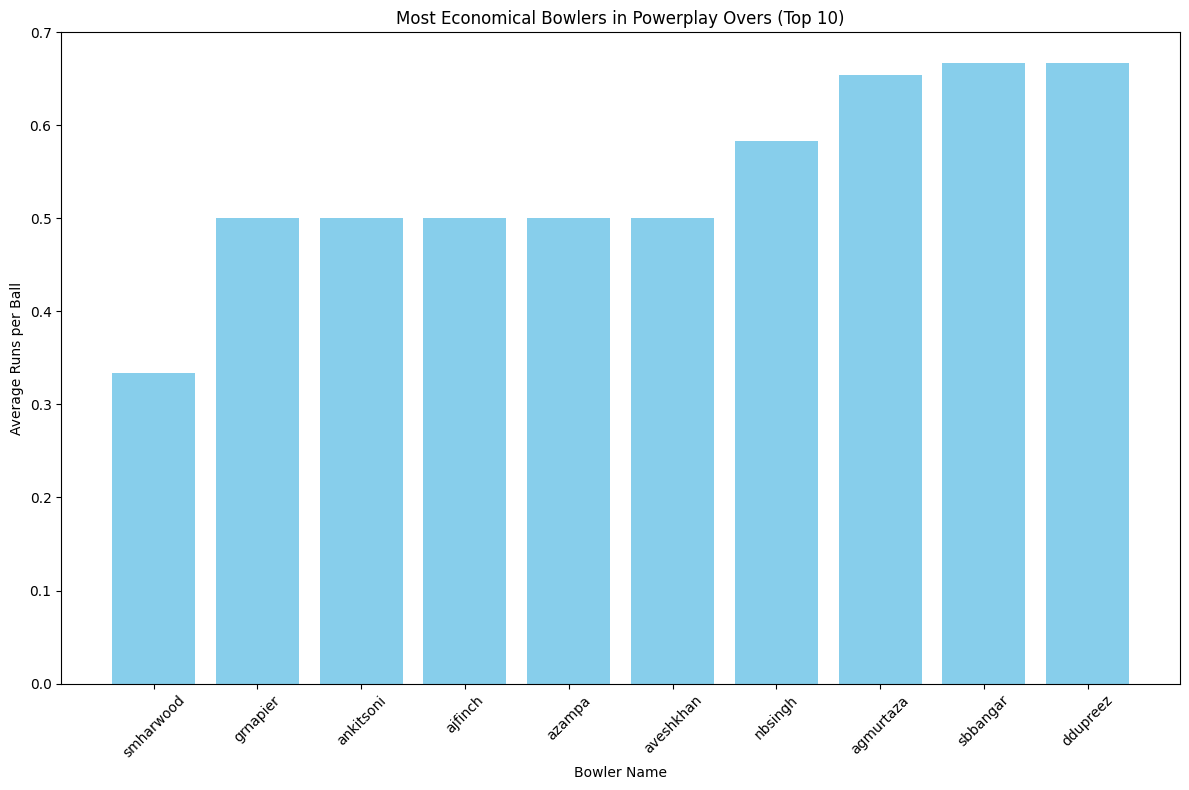

In [ ]:
#Assuming 'economical_bowlers_powerplay' is already executed and available as a Spark DataFrame
import matplotlib.pyplot as plt

economical_bowlers_pd = economical_bowlers_powerplay.toPandas()

plt.figure(figsize=(12,8))
top_economical_bowlers = economical_bowlers_pd.nsmallest(10, 'avg_runs_per_ball')
plt.bar(top_economical_bowlers['player_name'], top_economical_bowlers['avg_runs_per_ball'],color='skyblue')
plt.xlabel('Bowler Name')
plt.ylabel('Average Runs per Ball')
plt.title('Most Economical Bowlers in Powerplay Overs (Top 10)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


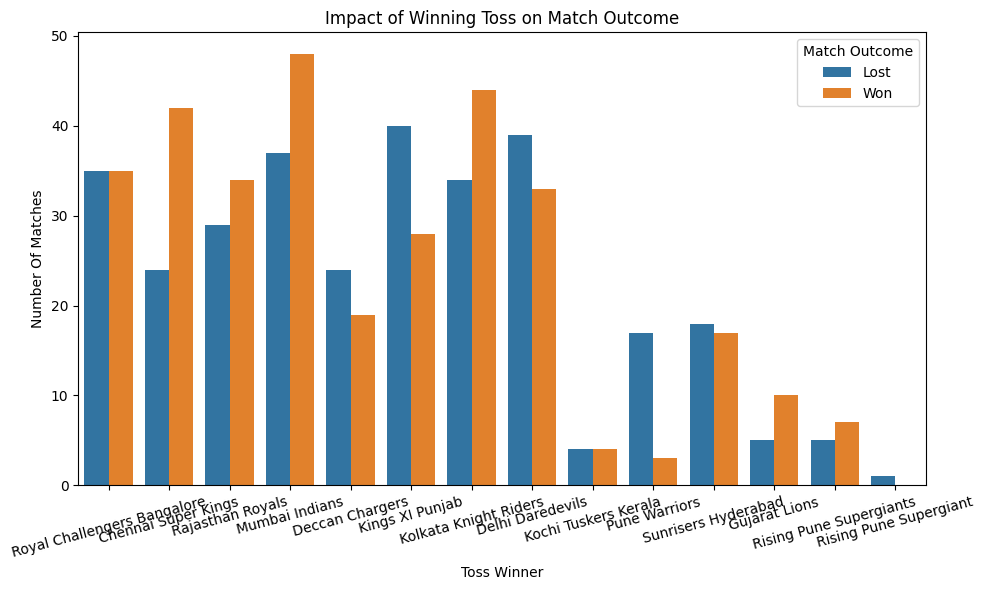

In [ ]:
import seaborn as sns

toss_impact_pd = toss_impact_individual_matches.toPandas()

#Creating a countplot to show win/loss after winning toss
plt.figure(figsize=(10,6))
sns.countplot(x='toss_winner',hue='match_outcome',data=toss_impact_pd)

plt.xlabel('Toss Winner')
plt.ylabel('Number Of Matches')
plt.title("Impact of Winning Toss on Match Outcome")
plt.legend(title='Match Outcome')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [ ]:
spark.stop()